# Introduction

<img src="https://www.kaggle.com/competitions/91715/images/header" width="600">

In this competition, we aim to develop a machine learning model to predict the **expected listening time** (in minutes) for podcast episodes based on a variety of content and contextual features.

Understanding how long users engage with audio content is crucial for improving podcast recommendations, optimizing ad placements, and enhancing the overall user experience. The dataset offers a mix of numerical and categorical features related to podcast metadata, popularity, scheduling, and monetization.

## Dataset Overview
- **Train Dataset:** 750,000 entries with 11 features including the target (`Listening_Time_minutes`).
- **Test Dataset:** 250,000 entries with the same features (excluding the target).
- **Features:** Includes episode length, guest popularity, podcast name/genre, number of ads, publication day & time, and popularity indicators.

## Our EDA Objectives:
🔍 **Data Quality Check:** Identify missing values, data types, and inconsistent entries.<br>
📊 **Feature Distributions:** Compare how features vary across train and test sets.<br>
📈 **Correlation Analysis:** Analyze how features relate to listening time and detect key predictors.<br>
🎙️ **Podcast Behavior Trends:** Explore how content length, popularity, and timing affect listener engagement.<br>
⚠️ **Outliers & Skewness:** Detect extreme values or skewed distributions that could affect model training.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv', index_col='id')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

## Data Description

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 750000 non-null  object 
 1   Episode_Title                750000 non-null  object 
 2   Episode_Length_minutes       662907 non-null  float64
 3   Genre                        750000 non-null  object 
 4   Host_Popularity_percentage   750000 non-null  float64
 5   Publication_Day              750000 non-null  object 
 6   Publication_Time             750000 non-null  object 
 7   Guest_Popularity_percentage  603970 non-null  float64
 8   Number_of_Ads                749999 non-null  float64
 9   Episode_Sentiment            750000 non-null  object 
 10  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 68.7+ MB


In [4]:
train.head()

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
id,,,,,,,,,,,
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [5]:
train.shape

(750000, 11)

In [6]:
train.isnull().sum()

Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [7]:
for column in train.columns:
    unique_values = train[column].unique()
    print(f"Column: {column}")
    print(f"Unique Values ({len(unique_values)}): {unique_values}")
    print("-" * 50)

Column: Podcast_Name
Unique Values (48): ['Mystery Matters' 'Joke Junction' 'Study Sessions' 'Digital Digest'
 'Mind & Body' 'Fitness First' 'Criminal Minds' 'News Roundup'
 'Daily Digest' 'Music Matters' 'Sports Central' 'Melody Mix' 'Game Day'
 'Gadget Geek' 'Global News' 'Tech Talks' 'Sport Spot' 'Funny Folks'
 'Sports Weekly' 'Business Briefs' 'Tech Trends' 'Innovators'
 'Health Hour' 'Comedy Corner' 'Sound Waves' 'Brain Boost'
 "Athlete's Arena" 'Wellness Wave' 'Style Guide' 'World Watch' 'Humor Hub'
 'Money Matters' 'Healthy Living' 'Home & Living' 'Educational Nuggets'
 'Market Masters' 'Learning Lab' 'Lifestyle Lounge' 'Crime Chronicles'
 'Detective Diaries' 'Life Lessons' 'Current Affairs' 'Finance Focus'
 'Laugh Line' 'True Crime Stories' 'Business Insights' 'Fashion Forward'
 'Tune Time']
--------------------------------------------------
Column: Episode_Title
Unique Values (100): ['Episode 98' 'Episode 26' 'Episode 16' 'Episode 45' 'Episode 86'
 'Episode 19' 'Episode 47' 'E

In [8]:
print("\nSummary Statistics:\n", train.describe())


Summary Statistics:
        Episode_Length_minutes  Host_Popularity_percentage  \
count           662907.000000               750000.000000   
mean                64.504738                   59.859901   
std                 32.969603                   22.873098   
min                  0.000000                    1.300000   
25%                 35.730000                   39.410000   
50%                 63.840000                   60.050000   
75%                 94.070000                   79.530000   
max                325.240000                  119.460000   

       Guest_Popularity_percentage  Number_of_Ads  Listening_Time_minutes  
count                603970.000000  749999.000000           750000.000000  
mean                     52.236449       1.348855               45.437406  
std                      28.451241       1.151130               27.138306  
min                       0.000000       0.000000                0.000000  
25%                      28.380000       0.00000

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250000 entries, 750000 to 999999
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 250000 non-null  object 
 1   Episode_Title                250000 non-null  object 
 2   Episode_Length_minutes       221264 non-null  float64
 3   Genre                        250000 non-null  object 
 4   Host_Popularity_percentage   250000 non-null  float64
 5   Publication_Day              250000 non-null  object 
 6   Publication_Time             250000 non-null  object 
 7   Guest_Popularity_percentage  201168 non-null  float64
 8   Number_of_Ads                250000 non-null  float64
 9   Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), object(6)
memory usage: 21.0+ MB


In [10]:
test.head()

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
id,,,,,,,,,,
750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


In [11]:
test.shape

(250000, 10)

In [12]:
test.isnull().sum()

Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

In [13]:
for column in test.columns:
    unique_values = test[column].unique()
    print(f"Column: {column}")
    print(f"Unique Values ({len(unique_values)}): {unique_values}")
    print("-" * 50)

Column: Podcast_Name
Unique Values (48): ['Educational Nuggets' 'Sound Waves' 'Joke Junction' 'Comedy Corner'
 'Life Lessons' 'Money Matters' 'Mystery Matters' 'Gadget Geek'
 'Home & Living' 'True Crime Stories' 'Finance Focus' 'Innovators'
 'Crime Chronicles' 'Tech Talks' 'Style Guide' 'World Watch'
 'Sports Weekly' 'Global News' 'Humor Hub' 'Business Insights'
 'Sport Spot' 'Digital Digest' 'Fashion Forward' 'Sports Central'
 'Funny Folks' 'Tech Trends' 'Laugh Line' 'Detective Diaries'
 'Mind & Body' 'Fitness First' 'Tune Time' 'Lifestyle Lounge'
 'Business Briefs' 'Wellness Wave' 'Market Masters' 'Melody Mix'
 'Health Hour' 'Study Sessions' 'Daily Digest' 'Healthy Living'
 'Learning Lab' 'Music Matters' 'Brain Boost' 'Game Day' "Athlete's Arena"
 'Criminal Minds' 'Current Affairs' 'News Roundup']
--------------------------------------------------
Column: Episode_Title
Unique Values (100): ['Episode 73' 'Episode 23' 'Episode 11' 'Episode 50' 'Episode 43'
 'Episode 33' 'Episode 24' 'E

In [14]:
print("\nSummary Statistics:\n", test.describe())


Summary Statistics:
        Episode_Length_minutes  Host_Popularity_percentage  \
count            2.212640e+05               250000.000000   
mean             4.192987e+02                   59.716491   
std              1.668545e+05                   22.880028   
min              2.470000e+00                    2.490000   
25%              3.578000e+01                   39.250000   
50%              6.397000e+01                   59.900000   
75%              9.415000e+01                   79.390000   
max              7.848626e+07                  117.760000   

       Guest_Popularity_percentage  Number_of_Ads  
count                201168.000000  250000.000000  
mean                     52.192796       1.355852  
std                      28.445034       4.274399  
min                       0.000000       0.000000  
25%                      28.320000       0.000000  
50%                      53.360000       1.000000  
75%                      76.560000       2.000000  
max         

| **Aspect**| **Train Summary**| **Test Summary**|
|--------------|--------------|--------------|
| **Observations** | 750,000 rows, 11 columns | 250,000 rows, 10 columns|
| **Target Column** | `Listening_Time_minutes` (present only in train set) | `Listening_Time_minutes` not included (Our target column) |
| **Missing Values** | `Episode_Length_minutes` (87,093 missing)  <br> `Guest_Popularity_percentage` (146,030 missing)  <br> `Number_of_Ads` (1 missing) | `Episode_Length_minutes` (28,736 missing)  <br> `Guest_Popularity_percentage` (48,832 missing) |
| **Podcast Coverage** | 48 unique podcast names | 48 unique podcast names – consistent coverage |
| **Episodes** | 100 unique titles (standard format) | 100 unique titles – consistent format |
| **Genres** | 10 genres (True Crime, Comedy, Education, etc.) <br> - Sports and Technology are most frequent <br> - Education is least frequent | Same 10 genres – consistent |
| **Publication Info** | 7 days, 4 times of day (Morning, Afternoon, Evening, Night) <br> - Night and Evening are popular times | Same – consistent |
| **Feature Variability** | - `Episode_Length_minutes`: mean ≈ 64.5 mins, max ≈ 325 mins  <br> - `Number_of_Ads`: most values small (0–3), outliers exist (max ≈ 104) <br> - `Guest_Popularity_percentage`: bounded around 0–120% range | - Similar variability  <br> - Outliers in Number_of_Ads (max = 2063), possibly erroneous  <br> - `Episode_Length_minutes` has a max of 78 million – likely a data entry error |
| **Data Quality** | Mostly clean with minor missing values and outliers needing attention | Missing values and several outlier issues, especially in Episode_Length_minutes and Number_of_Ads |
| **Sentiment Labels** | 3 classes: Positive, Neutral, Negative | Same 3 classes – consistent |
| **Numeric Features** | 5 numeric columns: Episode_Length_minutes, Host_Popularity_percentage, Guest_Popularity_percentage, Number_of_Ads, Listening_Time_minutes | 4 numeric columns (excluding target) |
| **Categorical Features**| `Podcast_Name`, `Episode_Title`, `Genre`, `Day_of_Week`, `Time_of_Day`, `Episode_Sentiment_Label` | Same - consistent |

## Data Visualization

In [15]:
numerical_cols = [col for col in train.columns if col in test.columns and train[col].dtype in ['float64', 'int64']]
numerical_cols

['Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Guest_Popularity_percentage',
 'Number_of_Ads']

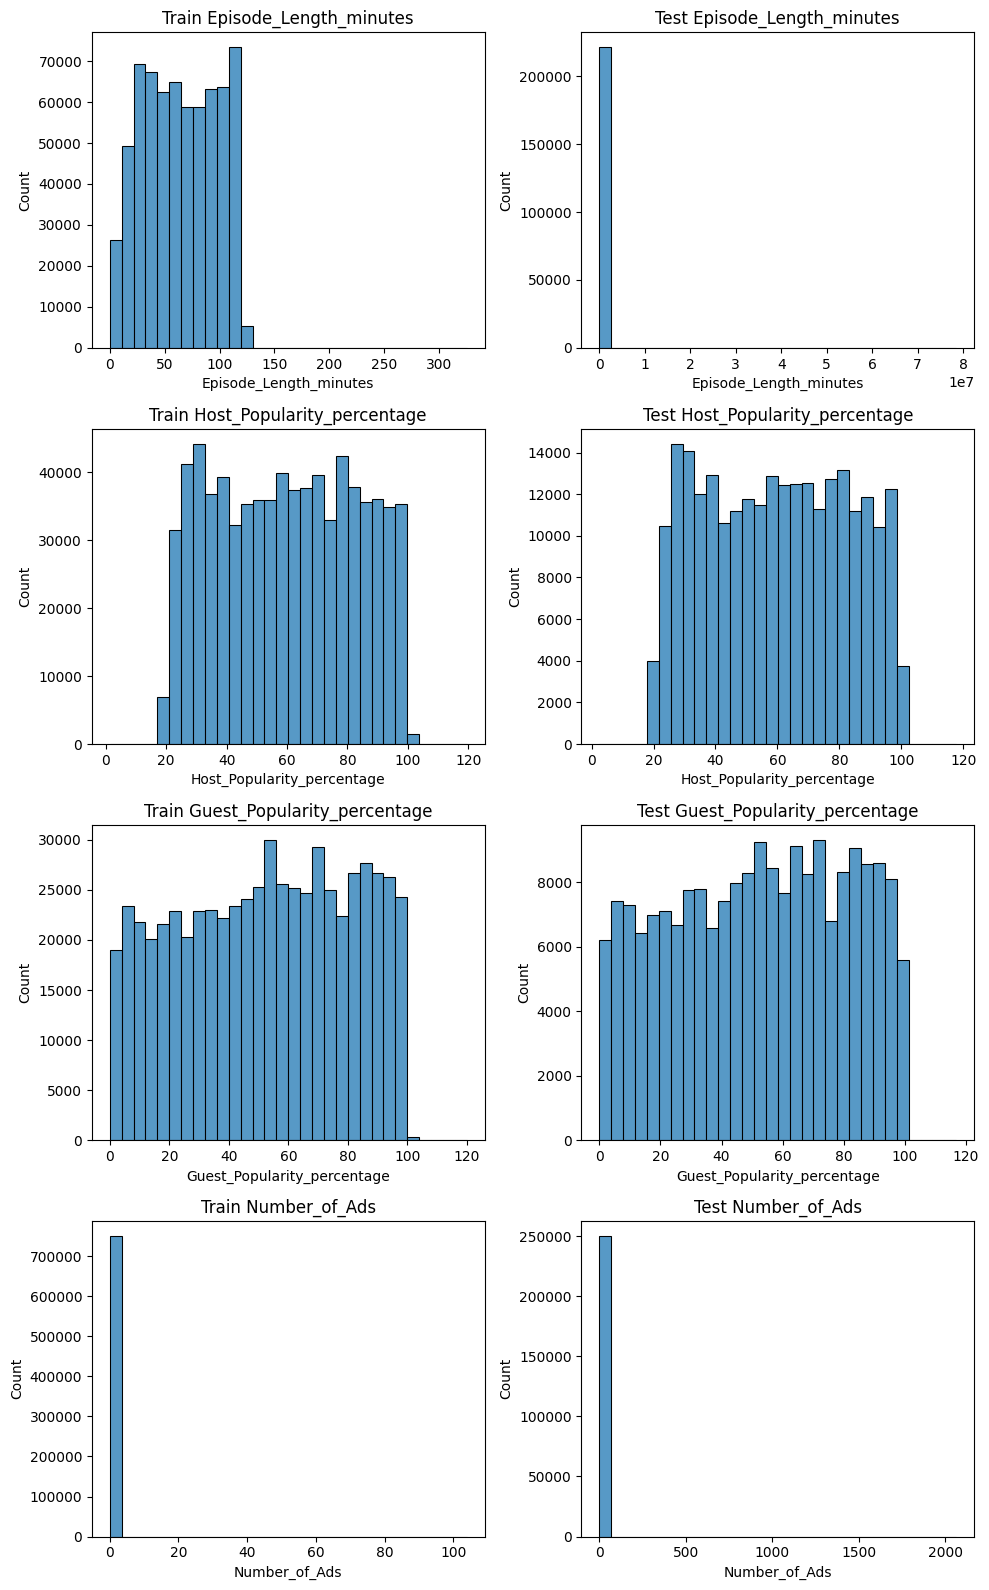

In [16]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(10, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    sns.histplot(train[col], bins=30, edgecolor='black', ax=axes[i][0])
    axes[i][0].set_title(f"Train {col}")

    sns.histplot(test[col], bins=30, edgecolor='black', ax=axes[i][1])
    axes[i][1].set_title(f"Test {col}")

plt.tight_layout()
plt.show()

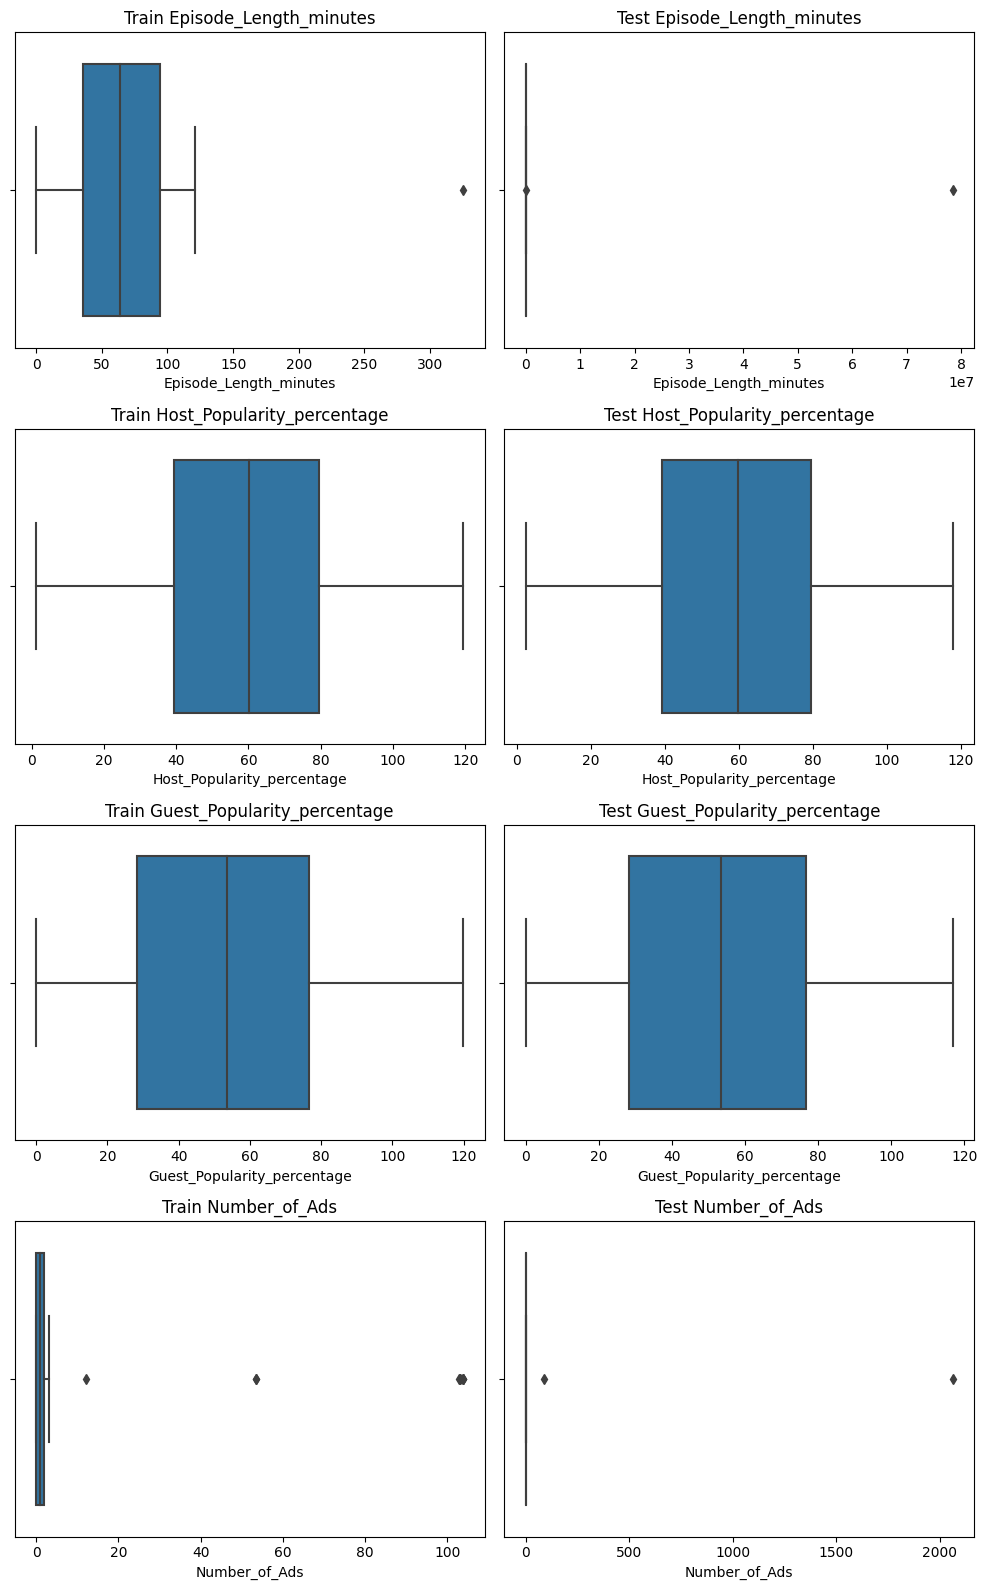

In [17]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(10, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=train[col], ax=axes[i][0])
    axes[i][0].set_title(f"Train {col}")
    
    sns.boxplot(x=test[col], ax=axes[i][1])
    axes[i][1].set_title(f"Test {col}")

plt.tight_layout()
plt.show()

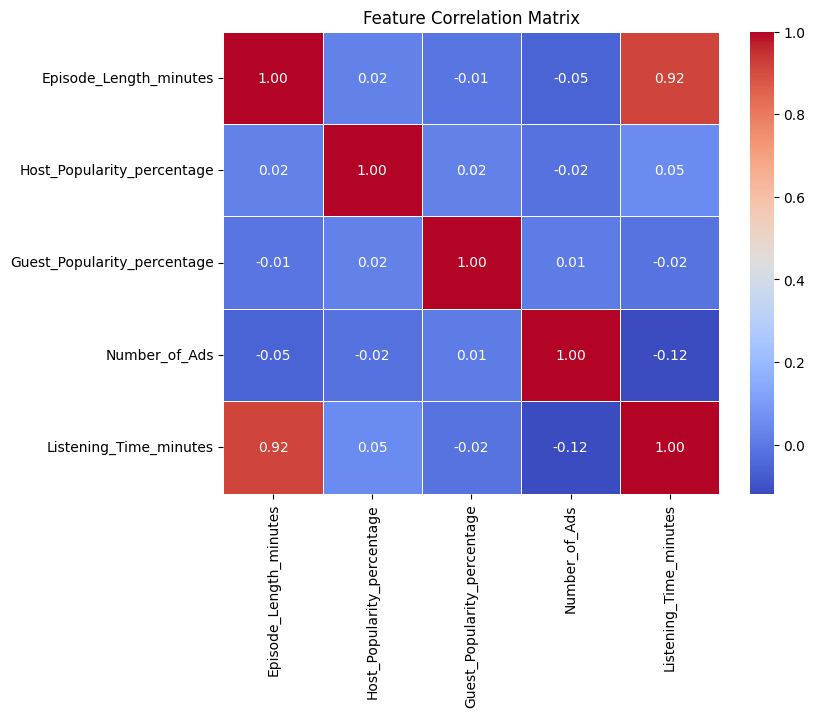

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

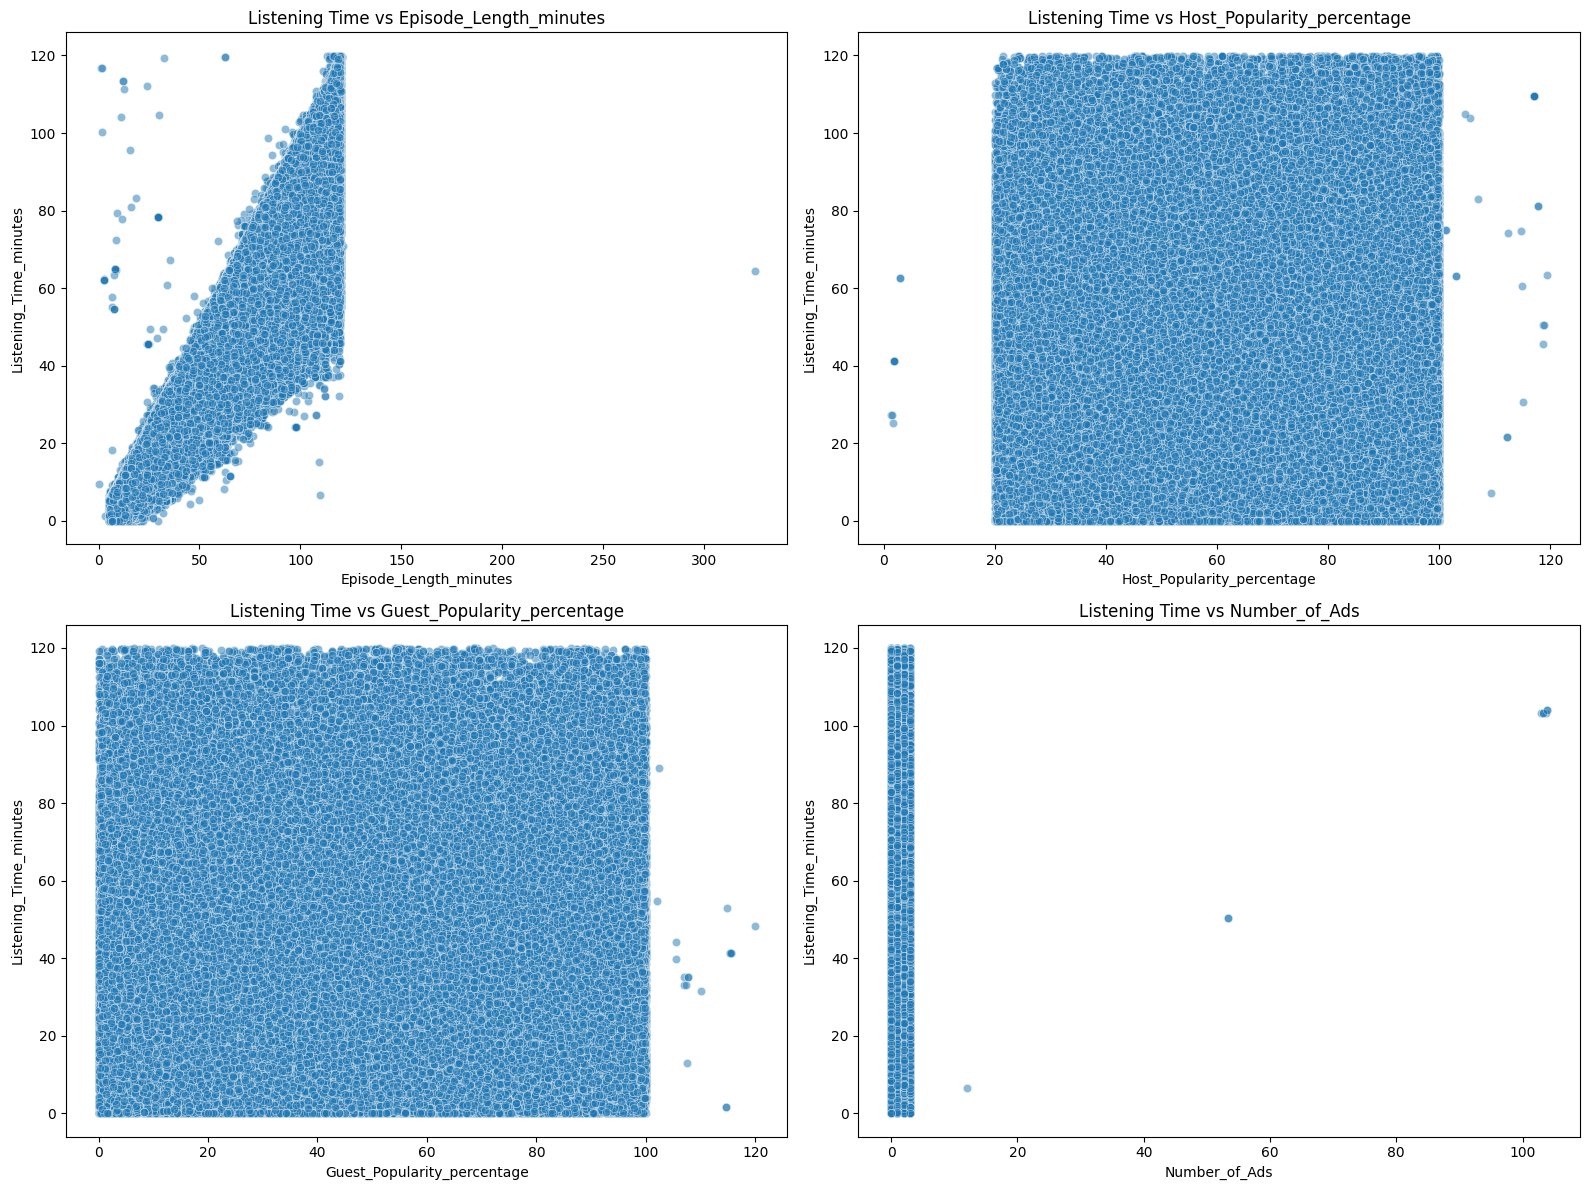

In [19]:
features = ['Episode_Length_minutes', 'Host_Popularity_percentage', 
            'Guest_Popularity_percentage', 'Number_of_Ads']

plt.figure(figsize=(16, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=train, x=feature, y='Listening_Time_minutes', alpha=0.5)
    plt.title(f'Listening Time vs {feature}')
    plt.tight_layout()

plt.show()

In [20]:
train_copy = train.copy().assign(Dataset='Train')
test_copy = test.copy().assign(Dataset='Test', Listening_Time_minutes=None)

combined = pd.concat([train_copy, test_copy])

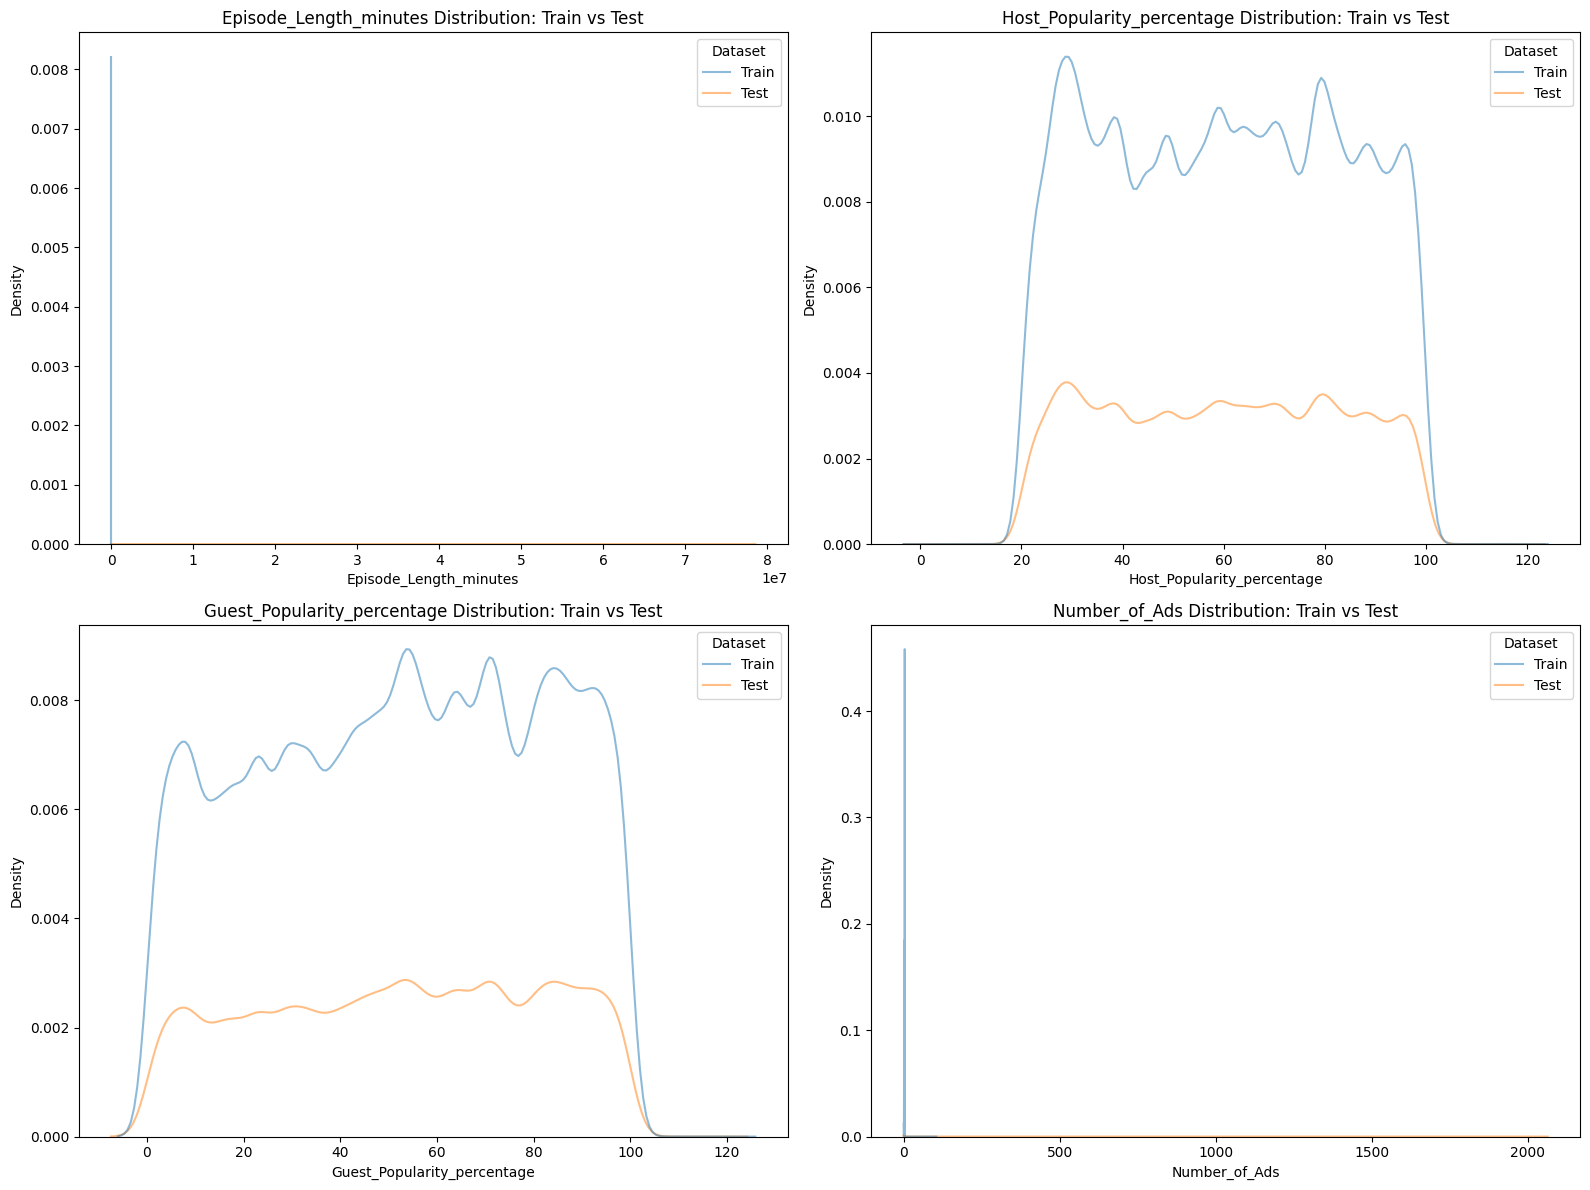

In [21]:
num_cols = ['Episode_Length_minutes', 'Host_Popularity_percentage', 
            'Guest_Popularity_percentage', 'Number_of_Ads']

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=combined, x=col, hue='Dataset', alpha=0.5)
    plt.title(f'{col} Distribution: Train vs Test')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

## 🎧 EDA Summary – Podcast Listening Prediction

#### 📊 Dataset Snapshot
- **Train**: 750,000 rows × 11 features  
- **Test**: 250,000 rows × 10 features (no target column i.e. `Listening_Time_minutes`)

### 🧠 Key Observations

#### 🎙 Feature Consistency
- **Podcast Names/Genres**: 48 names, 10 genres – consistent across both sets  
- **Episode Titles**: 100 standardized titles  
- **Publication**: Even spread across 7 days & 4 time slots

#### 📈 Numerical Analysis
- **Episode Length**:  
  - Train: Mean ≈ 64.5 mins  
  - Test: **Extreme outliers** (max ≈ 78 million) → cleaning required  
- **Popularity %**: Mostly within 0–120%, moderate skew  
- **Number of Ads**:  
  - Train: 0–3 ads mostly 
  - Test: Outliers (max = 2063) → potential entry issues

#### 🔗 Correlations
- **Listening Time ↔ Episode Length**: **Strong (0.92)**  
- Others: weak or no direct correlation with target

### ⚠️ Data Quality
- **Missing Values**:  
  - `Episode_Length_minutes`: 87K (train), 28K (test) [Both are ~11.6 %]
  - `Guest_Popularity_percentage`: 146K (train), 48K (test) [Both are ~19.5 %]
- **Outliers**: Must be addressed in episode length and ad count

## 🛠️ Feature Engineering Recommendations
- **Outlier Handling**: Cap/fix extreme values in `Episode_Length_minutes`, `Number_of_Ads`  
- **Missing Value Imputation**: Use group-wise mean/median or model-based (KNN, LightGBM)  
- **Skew Fixes**: Apply `log1p`/`sqrt` to skewed numeric features  
- **Interaction Features** like `Effective_Length = Episode_Length × (1 - Ads%)`  
- **Categorical Encoding**: One-hot or target encoding for `Podcast_Genre`, `Publication_Day`, `Time_of_Day`


## 🤖 Modeling Suggestions
- **Baseline**: Ridge/Lasso/ElasticNet for quick insights  
- **Tree-Based**: LightGBM / XGBoost – great with mixed data & non-linear interactions  
- **Neural Networks**: For deeper patterns, especially with embeddings for categorical features  
- **Ensembling**: Combine models to leverage strengths (e.g., LGBM + NN)